# 06 — Team Tier Trajectory (Bonus)
Scatter: T2 map win rate vs. T1 map win rate for teams playing in both tiers.


In [1]:
import sys, os; sys.path.insert(0, os.path.abspath('..'))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

from eda.utils import load_tables, enrich_matches, get_working_matches, get_completed_maps, savefig
teams_df = pd.read_parquet(os.path.join(os.path.abspath('..'), 'output', 'teams.parquet'))

tables = load_tables()
matches = enrich_matches(tables['matches'])
working = get_working_matches(matches)
comp_maps = get_completed_maps(tables['maps'], working)


In [2]:
# Build team × map win/loss records with roster continuity (>= 3 players in common between T1 and T2)
pstats = tables['map_player_stats']
pstats_w = pstats[pstats['map_id'].isin(comp_maps['map_id'])].merge(comp_maps[['map_id', 'tier']], on='map_id', how='inner')

# Find T2 players for each team
t2_stats = pstats_w[pstats_w['tier'] == 'tier2']
t2_players = t2_stats.groupby('team_id')['player_name'].apply(set).to_dict()

# Map-level player lists in T1
t1_stats = pstats_w[pstats_w['tier'] == 'tier1']
t1_map_players = t1_stats.groupby(['map_id', 'team_id'])['player_name'].apply(list).reset_index()

def get_common_count(row):
    team_id = row['team_id']
    players = row['player_name']
    if team_id not in t2_players:
        return 0
    t2_set = t2_players[team_id]
    return len([p for p in players if p in t2_set])

t1_map_players['common_players'] = t1_map_players.apply(get_common_count, axis=1)
valid_t1_maps = t1_map_players[t1_map_players['common_players'] >= 3]
valid_t1_map_ids = set(valid_t1_maps['map_id'])

# Build team outcomes for T2 (all T2 maps)
t2_outcomes = comp_maps[comp_maps['tier'] == 'tier2'].copy()
t2_team_outcomes = pd.concat([
    t2_outcomes[['match_id','map_id','tier','map_winner_id','team1_id']].rename(columns={'team1_id':'team_id'}),
    t2_outcomes[['match_id','map_id','tier','map_winner_id','team2_id']].rename(columns={'team2_id':'team_id'})
])
t2_team_outcomes['won'] = (t2_team_outcomes['team_id'] == t2_team_outcomes['map_winner_id']).astype(int)

# Build team outcomes for T1 (only valid maps with 3+ player overlap)
t1_outcomes = comp_maps[comp_maps['map_id'].isin(valid_t1_map_ids)].copy()
t1_team_outcomes = pd.concat([
    t1_outcomes[['match_id','map_id','tier','map_winner_id','team1_id']].rename(columns={'team1_id':'team_id'}),
    t1_outcomes[['match_id','map_id','tier','map_winner_id','team2_id']].rename(columns={'team2_id':'team_id'})
])
t1_team_outcomes = t1_team_outcomes.merge(valid_t1_maps[['map_id', 'team_id']], on=['map_id', 'team_id'], how='inner')
t1_team_outcomes['won'] = (t1_team_outcomes['team_id'] == t1_team_outcomes['map_winner_id']).astype(int)

# Combine outcomes and calculate winrates
all_outcomes = pd.concat([t2_team_outcomes, t1_team_outcomes])
team_tier_wr = (all_outcomes.groupby(['team_id','tier'])
                .agg(maps_played=('map_id','count'), maps_won=('won','sum'))
                .reset_index())
team_tier_wr['winrate'] = team_tier_wr['maps_won'] / team_tier_wr['maps_played']

# Pivot and filter by MIN_MAPS = 20
MIN_MAPS = 20
both = (team_tier_wr[team_tier_wr['maps_played'] >= MIN_MAPS]
        .pivot(index='team_id', columns='tier', values='winrate')
        .dropna())

counts = (team_tier_wr[team_tier_wr['maps_played'] >= MIN_MAPS]
          .pivot(index='team_id', columns='tier', values='maps_played')
          .dropna())
counts.columns = [f'{col}_maps' for col in counts.columns]

both = both.merge(counts, on='team_id').reset_index()
both = both.merge(teams_df[['team_id','name']], on='team_id', how='left')
both['dropoff'] = both['tier1'] - both['tier2']

print(f"Teams with {MIN_MAPS}+ maps in both T1 (with 3+ roster overlap) and T2: {len(both)}")


Teams with 20+ maps in both T1 (with 3+ roster overlap) and T2: 56


R²: 0.008  |  slope: 0.07  |  intercept: 0.50
Saved → /Users/francis/school/y2/t3/model/valorant/eda/figures/06_team_trajectory.png


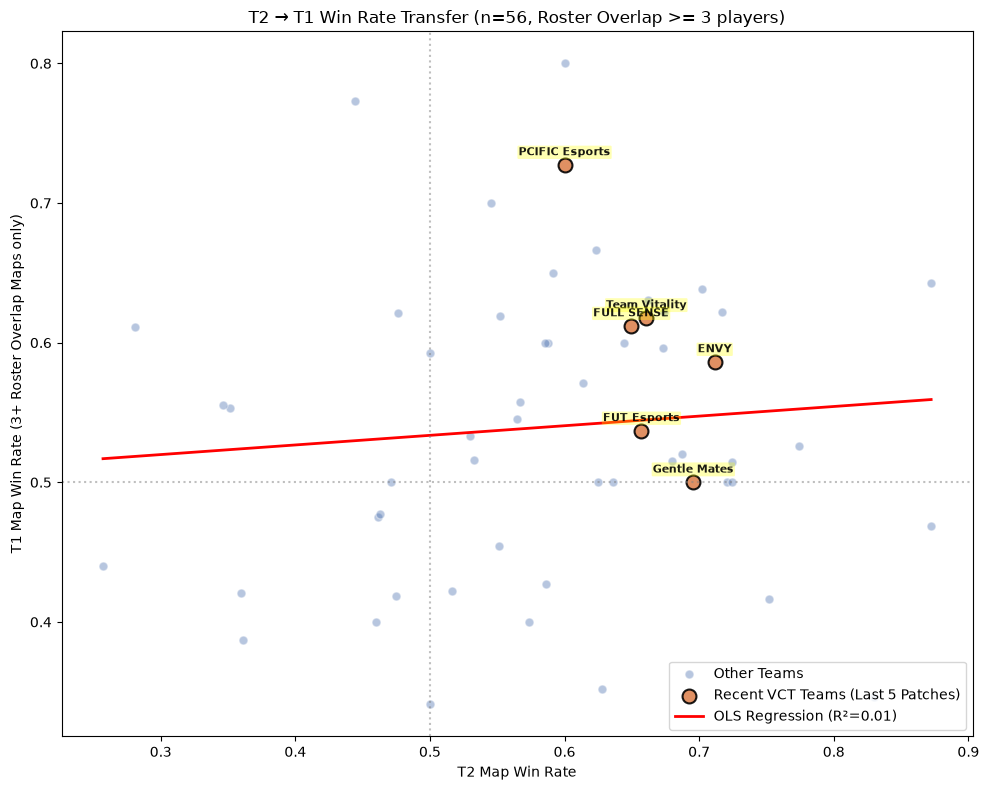


=== Recent VCT Teams in Plot ===
          name    tier2  tier2_maps    tier1  tier1_maps   dropoff
   FUT Esports 0.657143        70.0 0.536842        95.0 -0.120301
  Gentle Mates 0.695652        23.0 0.500000        48.0 -0.195652
 Team Vitality 0.660714        56.0 0.617647       102.0 -0.043067
PCIFIC Esports 0.600000        45.0 0.727273        22.0  0.127273
    FULL SENSE 0.649485       194.0 0.611940        67.0 -0.037544
          ENVY 0.711538        52.0 0.586207        29.0 -0.125332


In [3]:
# OLS regression
X = both['tier2'].values.reshape(-1,1)
y = both['tier1'].values
reg = LinearRegression().fit(X, y)
print(f"R²: {reg.score(X, y):.3f}  |  slope: {reg.coef_[0]:.2f}  |  intercept: {reg.intercept_:.2f}")

# Identify recent VCT teams in the last 5 patches
target_patches = ['13.0', '12.11', '12.10', '12.09', '12.08']
recent_vct = working[(working['tier'] == 'tier1') & (working['patch'].isin(target_patches))]
recent_teams = set(recent_vct['team1_id'].dropna()).union(set(recent_vct['team2_id'].dropna()))

both['recent'] = both['team_id'].isin(recent_teams)
both_recent = both[both['recent']]
both_other = both[~both['recent']]

fig, ax = plt.subplots(figsize=(10, 8))

# Plot background teams
ax.scatter(both_other['tier2'], both_other['tier1'],
           s=40, alpha=0.4, c='#4C72B0', edgecolors='white', label='Other Teams')

# Plot highlighted recent teams
ax.scatter(both_recent['tier2'], both_recent['tier1'],
           s=100, alpha=0.9, c='#DD8452', edgecolors='black', linewidth=1.5, label='Recent VCT Teams (Last 5 Patches)')

# Plot OLS regression line
x_range = np.linspace(both['tier2'].min(), both['tier2'].max(), 100)
ax.plot(x_range, reg.predict(x_range.reshape(-1,1)), color='red', linewidth=2,
        label=f'OLS Regression (R²={reg.score(X,y):.2f})')

# Gridlines & reference lines
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
ax.axvline(0.5, color='gray', linestyle=':', alpha=0.5)

# Axis labels & title
ax.set_xlabel('T2 Map Win Rate')
ax.set_ylabel('T1 Map Win Rate (3+ Roster Overlap Maps only)')
ax.set_title(f'T2 → T1 Win Rate Transfer (n={len(both)}, Roster Overlap >= 3 players)')

# Annotate all recent VCT teams
for _, row in both_recent.iterrows():
    ax.annotate(row['name'], (row['tier2'], row['tier1']),
                textcoords="offset points", xytext=(0, 7), ha='center',
                fontsize=8, fontweight='bold', alpha=0.9,
                bbox=dict(boxstyle="round,pad=0.1", fc="yellow", alpha=0.3, ec="none"))

ax.legend(loc='lower right')
plt.tight_layout()
savefig(fig, '06_team_trajectory')
plt.show()

# Print statistics of recent VCT teams
print("\n=== Recent VCT Teams in Plot ===")
print(both_recent[['name', 'tier2', 'tier2_maps', 'tier1', 'tier1_maps', 'dropoff']].to_string(index=False))


R²: 0.098  |  slope: 0.33  |  intercept: 0.26


Saved → /Users/francis/school/y2/t3/model/valorant/eda/figures/06_team_trajectory_all.png


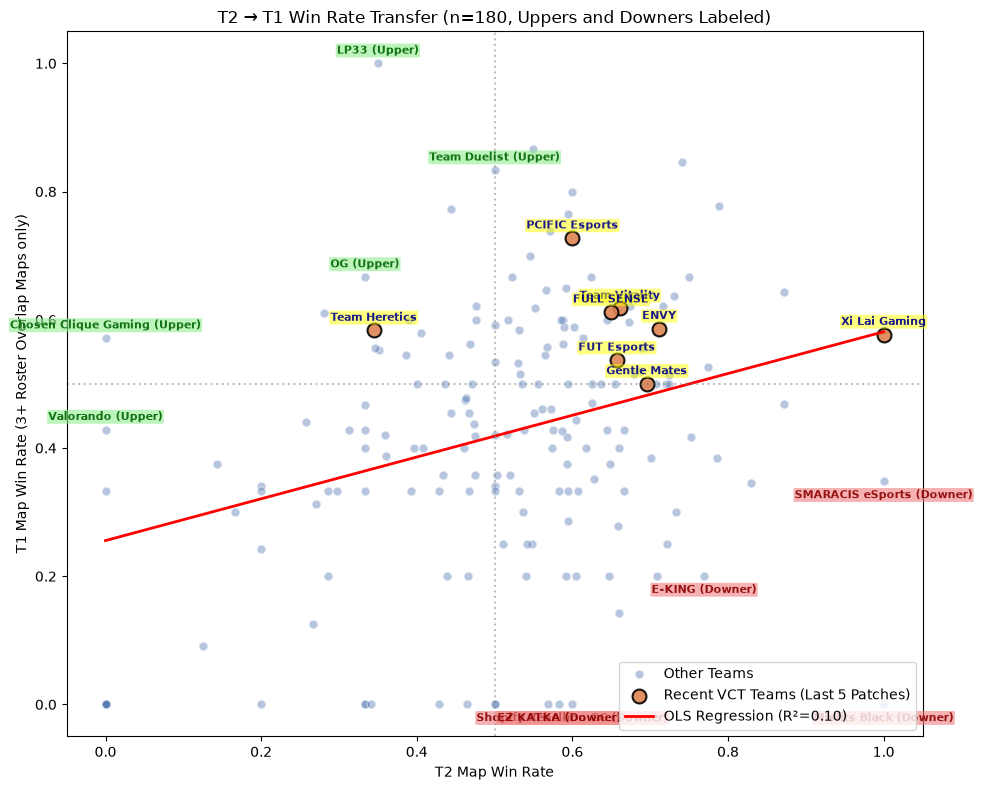


=== Recent VCT Teams (No Map Filter) ===
          name    tier2  tier2_maps    tier1  tier1_maps   dropoff
 Team Heretics 0.344828        29.0 0.583333        12.0  0.238506
   FUT Esports 0.657143        70.0 0.536842        95.0 -0.120301
  Gentle Mates 0.695652        23.0 0.500000        48.0 -0.195652
 Xi Lai Gaming 1.000000         5.0 0.576923        26.0 -0.423077
 Team Vitality 0.660714        56.0 0.617647       102.0 -0.043067
PCIFIC Esports 0.600000        45.0 0.727273        22.0  0.127273
    FULL SENSE 0.649485       194.0 0.611940        67.0 -0.037544
          ENVY 0.711538        52.0 0.586207        29.0 -0.125332


In [4]:
# %%
# 6b. Trajectory plot with MIN_MAPS = 1 (All teams with any T1 and T2 maps)

# Pivot with MIN_MAPS = 1
both_all = (team_tier_wr[team_tier_wr['maps_played'] >= 1]
            .pivot(index='team_id', columns='tier', values='winrate')
            .dropna())

counts_all = (team_tier_wr[team_tier_wr['maps_played'] >= 1]
              .pivot(index='team_id', columns='tier', values='maps_played')
              .dropna())
counts_all.columns = [f'{col}_maps' for col in counts_all.columns]

both_all = both_all.merge(counts_all, on='team_id').reset_index()
both_all = both_all.merge(teams_df[['team_id','name']], on='team_id', how='left')
both_all['dropoff'] = both_all['tier1'] - both_all['tier2']

# OLS Regression
X_all = both_all['tier2'].values.reshape(-1,1)
y_all = both_all['tier1'].values
reg_all = LinearRegression().fit(X_all, y_all)
print(f"R²: {reg_all.score(X_all, y_all):.3f}  |  slope: {reg_all.coef_[0]:.2f}  |  intercept: {reg_all.intercept_:.2f}")

both_all['recent'] = both_all['team_id'].isin(recent_teams)
both_all_recent = both_all[both_all['recent']]
both_all_other = both_all[~both_all['recent']]

# Identify top 5 uppers and downers
uppers = both_all.sort_values(by='dropoff', ascending=False).head(5)
downers = both_all.sort_values(by='dropoff', ascending=True).head(5)

fig, ax = plt.subplots(figsize=(10, 8))

# Plot background teams
ax.scatter(both_all_other['tier2'], both_all_other['tier1'],
           s=40, alpha=0.4, c='#4C72B0', edgecolors='white', label='Other Teams')

# Plot highlighted recent teams
ax.scatter(both_all_recent['tier2'], both_all_recent['tier1'],
           s=100, alpha=0.9, c='#DD8452', edgecolors='black', linewidth=1.5, label='Recent VCT Teams (Last 5 Patches)')

# Plot OLS regression line
x_range = np.linspace(both_all['tier2'].min(), both_all['tier2'].max(), 100)
ax.plot(x_range, reg_all.predict(x_range.reshape(-1,1)), color='red', linewidth=2,
        label=f'OLS Regression (R²={reg_all.score(X_all,y_all):.2f})')

# Gridlines & reference lines
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
ax.axvline(0.5, color='gray', linestyle=':', alpha=0.5)

# Axis labels & title
ax.set_xlabel('T2 Map Win Rate')
ax.set_ylabel('T1 Map Win Rate (3+ Roster Overlap Maps only)')
ax.set_title(f'T2 → T1 Win Rate Transfer (n={len(both_all)}, Uppers and Downers Labeled)')

# Annotate all recent VCT teams
for _, row in both_all_recent.iterrows():
    ax.annotate(row['name'], (row['tier2'], row['tier1']),
                textcoords="offset points", xytext=(0, 7), ha='center',
                fontsize=8, fontweight='bold', color='darkblue', alpha=0.9,
                bbox=dict(boxstyle="round,pad=0.1", fc="yellow", alpha=0.5, ec="none"))

# Annotate top 5 uppers (excluding if already annotated as recent, but they are distinct)
for _, row in uppers.iterrows():
    if row['team_id'] not in both_all_recent['team_id'].values:
        ax.annotate(row['name'] + ' (Upper)', (row['tier2'], row['tier1']),
                    textcoords="offset points", xytext=(0, 7), ha='center',
                    fontsize=8, fontweight='bold', color='darkgreen', alpha=0.9,
                    bbox=dict(boxstyle="round,pad=0.1", fc="lightgreen", alpha=0.6, ec="none"))

# Annotate top 5 downers
for _, row in downers.iterrows():
    if row['team_id'] not in both_all_recent['team_id'].values:
        ax.annotate(row['name'] + ' (Downer)', (row['tier2'], row['tier1']),
                    textcoords="offset points", xytext=(0, -12), ha='center', # offset downwards for downers
                    fontsize=8, fontweight='bold', color='darkred', alpha=0.9,
                    bbox=dict(boxstyle="round,pad=0.1", fc="lightcoral", alpha=0.6, ec="none"))

ax.legend(loc='lower right')
plt.tight_layout()
savefig(fig, '06_team_trajectory_all')
plt.show()

# Print statistics of recent VCT teams
print("\n=== Recent VCT Teams (No Map Filter) ===")
print(both_all_recent[['name', 'tier2', 'tier2_maps', 'tier1', 'tier1_maps', 'dropoff']].to_string(index=False))
